In [1]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

C:\Users\JimmyWu\.conda\envs\fds_cw3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## TensorFlow augmentation 5 methods 

In [2]:
SEED = 42
BATCH_SIZE = 64
EPOCHS = 10

tf.random.set_seed(SEED)
np.random.seed(SEED)

# -----------------------------
# EN: A safe "no-op" layer for Method 0 (no augmentation).
# CN: 用于 Method 0 的“空增强层”，避免 Sequential 没有 layer 报错
# -----------------------------
class IdentityLayer(tf.keras.layers.Layer):
    def call(self, x, training=None):
        return x

# -----------------------------
# EN: Choose TensorFlow augmentation by method_id (0~4).
# CN: 根据 method_id 选择 TensorFlow 增强策略（0~4），二分法之外你这里是“5种方案对比”
# -----------------------------
def get_augmentation(method_id: int, is_rgb: bool) -> tf.keras.Model:
    """
    Method 0: No augmentation (Identity).
    Method 1: Rotation.
    Method 2: Translation.
    Method 3: Zoom.
    Method 4: Rotation + Translation + Zoom (+ Contrast for RGB).
    """
    if method_id == 0:
        # EN: No augmentation.
        # CN: 不增强，返回一个恒等映射层
        return tf.keras.Sequential([IdentityLayer()], name="aug_none")

    layers = []
    if method_id == 1:
        layers.append(tf.keras.layers.RandomRotation(0.08))
    elif method_id == 2:
        layers.append(tf.keras.layers.RandomTranslation(0.08, 0.08))
    elif method_id == 3:
        layers.append(tf.keras.layers.RandomZoom(0.10))
    elif method_id == 4:
        layers.append(tf.keras.layers.RandomRotation(0.08))
        layers.append(tf.keras.layers.RandomTranslation(0.08, 0.08))
        layers.append(tf.keras.layers.RandomZoom(0.10))
        if is_rgb:
            layers.append(tf.keras.layers.RandomContrast(0.10))

    return tf.keras.Sequential(layers, name=f"aug_{method_id}")

# -----------------------------
# EN: Simple CNN baseline (same architecture across methods).
# CN: 统一 CNN 模型结构（保证对比公平）
# -----------------------------
def build_cnn(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# -----------------------------
# EN: Train one method and return history + final train/val accuracy.
# CN: 训练单个增强方案，返回 history + 最终训练/验证准确率（便于判断过拟合）
# -----------------------------
def run_one_method(X_train, y_train, X_val, y_val, input_shape, num_classes, method_id, is_rgb):
    aug = get_augmentation(method_id, is_rgb)

    # EN: Build tf.data pipeline.
    # CN: 用 tf.data 加速，并确保“只在训练集做增强”
    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
        .shuffle(min(len(X_train), 20000), seed=SEED) \
        .batch(BATCH_SIZE)

    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)

    # EN: Apply augmentation only for training.
    # CN: 仅训练集增强；验证集不做增强（评估公平）
    def train_map(x, y):
        x = aug(x, training=True)
        return x, y

    train_ds = train_ds.map(train_map, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

    model = build_cnn(input_shape, num_classes)
    history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=2)

    final_train_acc = history.history["accuracy"][-1]
    final_val_acc = history.history["val_accuracy"][-1]
    return history, final_train_acc, final_val_acc

# -----------------------------
# EN: Plot accuracy + loss curves.
# CN: 画训练/验证的 accuracy 与 loss 曲线
# -----------------------------
def plot_acc_loss(history, title_prefix=""):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

##  STL-10

C:\Users\JimmyWu\.conda\envs\fds_cw3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dl Completed...: 0 url [00:00, ? url/s]
Dl Size...: 0 MiB [00:00, ? MiB/s]

Dl Completed...:   0%|                                                                         | 0/1 [00:00<?, ? url/s]
Dl Size...: 0 MiB [00:00, ? MiB/s]

Dl Size...:   0%|                                                                           | 0/2518 [00:00<?, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]
Dl Size...:   0%|                                                                 | 1/2518 [00:04<3:03:43,  4.38s/ MiB]

Extraction completed...: 0 file [00:04, ? file/s]
Dl Size...:   0%|                                                                 | 2/2518 [00:05<1:51:01,  2.65s/ MiB]

Dl Size...:   0%|                                                                 | 3/2518 [00:06<1:50:58,  2.65s/ MiB]

Extraction completed...: 0 file [00:06, ? file/s]
Dl Size...:   0%|                                                                 | 4/2518 [00:07<1:00:37,  1.45s/ MiB]

Dl Size...:  

Dl Size...:   1%|▊                                                                 | 30/2518 [00:13<11:30,  3.60 MiB/s]

Dl Size...:   1%|▊                                                                 | 31/2518 [00:13<11:30,  3.60 MiB/s]

Dl Size...:   1%|▊                                                                 | 32/2518 [00:13<11:30,  3.60 MiB/s]

Extraction completed...: 0 file [00:13, ? file/s]
Dl Size...:   1%|▊                                                                 | 33/2518 [00:14<09:24,  4.40 MiB/s]

Dl Size...:   1%|▉                                                                 | 34/2518 [00:14<09:24,  4.40 MiB/s]

Dl Size...:   1%|▉                                                                 | 35/2518 [00:14<09:24,  4.40 MiB/s]

Dl Size...:   1%|▉                                                                 | 36/2518 [00:14<09:23,  4.40 MiB/s]

Dl Size...:   1%|▉                                                                 | 37/2518 [00:14<09:

Dl Size...:   3%|█▋                                                                | 63/2518 [00:17<05:18,  7.71 MiB/s]

Dl Size...:   3%|█▋                                                                | 64/2518 [00:17<05:18,  7.71 MiB/s]

Dl Size...:   3%|█▋                                                                | 65/2518 [00:17<05:18,  7.71 MiB/s]

Dl Size...:   3%|█▋                                                                | 66/2518 [00:17<05:18,  7.71 MiB/s]

Dl Size...:   3%|█▊                                                                | 67/2518 [00:17<05:18,  7.71 MiB/s]

Dl Size...:   3%|█▊                                                                | 68/2518 [00:17<05:17,  7.71 MiB/s]

Dl Size...:   3%|█▊                                                                | 69/2518 [00:17<05:17,  7.71 MiB/s]

Dl Size...:   3%|█▊                                                                | 70/2518 [00:17<05:17,  7.71 MiB/s]

Dl Size...:   3%|█▊             

Dl Size...:   4%|██▌                                                               | 96/2518 [00:19<03:47, 10.66 MiB/s]

Dl Size...:   4%|██▌                                                               | 97/2518 [00:19<03:47, 10.66 MiB/s]

Dl Size...:   4%|██▌                                                               | 98/2518 [00:19<03:46, 10.66 MiB/s]

Dl Size...:   4%|██▌                                                               | 99/2518 [00:19<03:46, 10.66 MiB/s]

Dl Size...:   4%|██▌                                                              | 100/2518 [00:20<03:46, 10.66 MiB/s]

Dl Size...:   4%|██▌                                                              | 101/2518 [00:20<03:46, 10.66 MiB/s]

Dl Size...:   4%|██▋                                                              | 102/2518 [00:20<03:46, 10.66 MiB/s]

Dl Size...:   4%|██▋                                                              | 103/2518 [00:20<03:46, 10.66 MiB/s]

Dl Size...:   4%|██▋            

...

Dl Size...: 100%|███████████████████████████████████████████████████████████████▉| 2517/2518 [03:55<00:00, 10.86 MiB/s]

Extraction completed...: 0 file [03:55, ? file/s]
Dl Size...: 100%|████████████████████████████████████████████████████████████████| 2518/2518 [03:55<00:00, 10.89 MiB/s]

Dl Size...: 100%|████████████████████████████████████████████████████████████████| 2518/2518 [03:55<00:00, 10.89 MiB/s]

Dl Size...: 100%|████████████████████████████████████████████████████████████████| 2518/2518 [03:56<00:00, 10.89 MiB/s]

Dl Size...: 100%|████████████████████████████████████████████████████████████████| 2518/2518 [03:56<00:00, 10.89 MiB/s]

Dl Size...: 100%|████████████████████████████████████████████████████████████████| 2518/2518 [03:57<00:00, 10.89 MiB/s]

Dl Size...: 100%|████████████████████████████████████████████████████████████████| 2518/2518 [03:57<00:00, 10.89 MiB/s]

Dl Size...: 100%|████████████████████████████████████████████████████████████████| 2518/2518 [04:08<00:

Generating unlabelled examples...: 12605 examples [00:18, 794.79 examples/s]
Generating unlabelled examples...: 13402 examples [00:19, 793.62 examples/s]
Generating unlabelled examples...: 14197 examples [00:20, 773.31 examples/s]
Generating unlabelled examples...: 14982 examples [00:21, 776.61 examples/s]
Generating unlabelled examples...: 15779 examples [00:22, 782.30 examples/s]
Generating unlabelled examples...: 16571 examples [00:23, 784.77 examples/s]
Generating unlabelled examples...: 17357 examples [00:24, 779.79 examples/s]
Generating unlabelled examples...: 18138 examples [00:25, 779.36 examples/s]
Generating unlabelled examples...: 18918 examples [00:26, 777.05 examples/s]
Generating unlabelled examples...: 19715 examples [00:27, 782.87 examples/s]
Generating unlabelled examples...: 20499 examples [00:28, 782.38 examples/s]
Generating unlabelled examples...: 21282 examples [00:29, 782.16 examples/s]
Generating unlabelled examples...: 22065 examples [00:30, 779.33 examples/s]

Generating unlabelled examples...: 91957 examples [02:04, 742.30 examples/s]
Generating unlabelled examples...: 92700 examples [02:05, 739.61 examples/s]
Generating unlabelled examples...: 93440 examples [02:06, 734.39 examples/s]
Generating unlabelled examples...: 94182 examples [02:07, 736.63 examples/s]
Generating unlabelled examples...: 94919 examples [02:08, 736.29 examples/s]
Generating unlabelled examples...: 95678 examples [02:09, 742.85 examples/s]
Generating unlabelled examples...: 96421 examples [02:10, 742.55 examples/s]
Generating unlabelled examples...: 97164 examples [02:11, 733.60 examples/s]
Generating unlabelled examples...: 97898 examples [02:12, 728.04 examples/s]
Generating unlabelled examples...: 98627 examples [02:13, 725.13 examples/s]
Generating unlabelled examples...: 99373 examples [02:14, 730.89 examples/s]
                                                                            
Shuffling C:\Users\JimmyWu\tensorflow_datasets\stl10\incomplete.0TIIIT_1.0.0

Dataset stl10 downloaded and prepared to C:\Users\JimmyWu\tensorflow_datasets\stl10\1.0.0. Subsequent calls will reuse this data.

STL-10 - Method 0



Epoch 1/10
163/163 - 2s - 11ms/step - accuracy: 0.3373 - loss: 1.7895 - val_accuracy: 0.4277 - val_loss: 1.5590
Epoch 2/10
163/163 - 1s - 6ms/step - accuracy: 0.4650 - loss: 1.4466 - val_accuracy: 0.4658 - val_loss: 1.4364
Epoch 3/10
163/163 - 1s - 6ms/step - accuracy: 0.5127 - loss: 1.3338 - val_accuracy: 0.5112 - val_loss: 1.3490
Epoch 4/10
163/163 - 1s - 6ms/step - accuracy: 0.5580 - loss: 1.2278 - val_accuracy: 0.5238 - val_loss: 1.3473
Epoch 5/10
163/163 - 1s - 6ms/step - accuracy: 0.5878 - loss: 1.1358 - val_accuracy: 0.5523 - val_loss: 1.2386
Epoch 6/10
163/163 - 1s - 6ms/step - accuracy: 0.6254 - loss: 1.0409 - val_accuracy: 0.5500 - val_loss: 1.2654
Epoch 7/10
163/163 - 1s - 6ms/step - accuracy: 0.6571 - loss: 0.9545 - val_accuracy: 0.5654 - val_loss: 1.2263
Epoch 8/10
163/163 - 1s - 6ms/step - accuracy: 0.6879 - loss: 0.8801 - val_accuracy: 0.5792 - val_loss: 1.1973
Epoch 9/10
163/163 - 1s - 6ms/step - accuracy: 0.7178 - loss: 0.7914 - val_accuracy: 0.5781 - val_loss: 1.2343


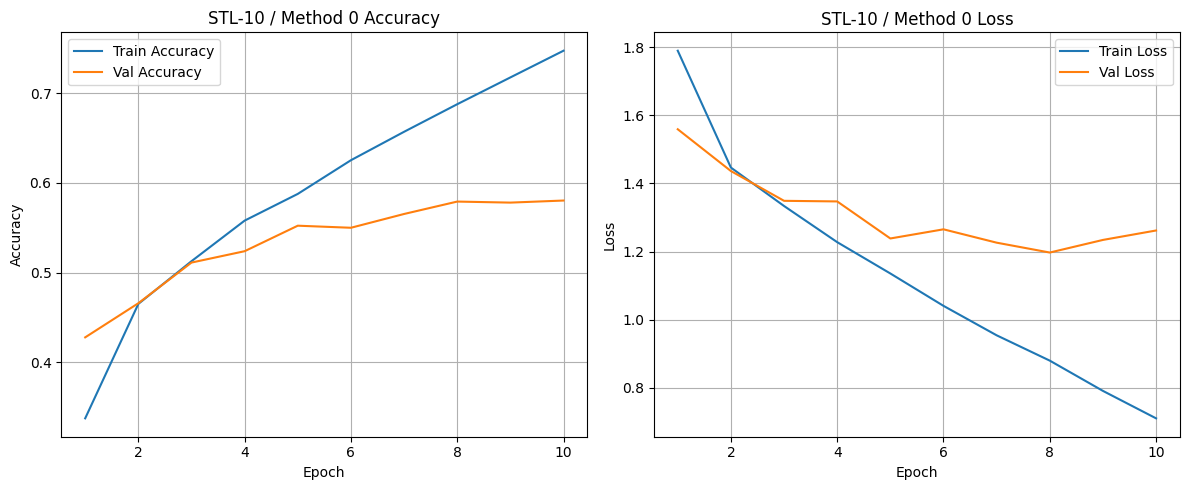


STL-10 - Method 1
Epoch 1/10
163/163 - 2s - 11ms/step - accuracy: 0.3263 - loss: 1.8038 - val_accuracy: 0.3958 - val_loss: 1.6227
Epoch 2/10
163/163 - 1s - 7ms/step - accuracy: 0.4465 - loss: 1.4888 - val_accuracy: 0.4519 - val_loss: 1.4365
Epoch 3/10
163/163 - 1s - 6ms/step - accuracy: 0.4834 - loss: 1.3952 - val_accuracy: 0.4642 - val_loss: 1.4848
Epoch 4/10
163/163 - 1s - 6ms/step - accuracy: 0.5233 - loss: 1.3181 - val_accuracy: 0.4862 - val_loss: 1.4701
Epoch 5/10
163/163 - 1s - 6ms/step - accuracy: 0.5460 - loss: 1.2541 - val_accuracy: 0.5285 - val_loss: 1.3205
Epoch 6/10
163/163 - 1s - 6ms/step - accuracy: 0.5648 - loss: 1.2190 - val_accuracy: 0.5312 - val_loss: 1.2635
Epoch 7/10
163/163 - 1s - 6ms/step - accuracy: 0.5828 - loss: 1.1631 - val_accuracy: 0.5358 - val_loss: 1.3262
Epoch 8/10
163/163 - 1s - 6ms/step - accuracy: 0.5919 - loss: 1.1319 - val_accuracy: 0.5758 - val_loss: 1.1878
Epoch 9/10
163/163 - 1s - 6ms/step - accuracy: 0.6056 - loss: 1.0997 - val_accuracy: 0.5492 

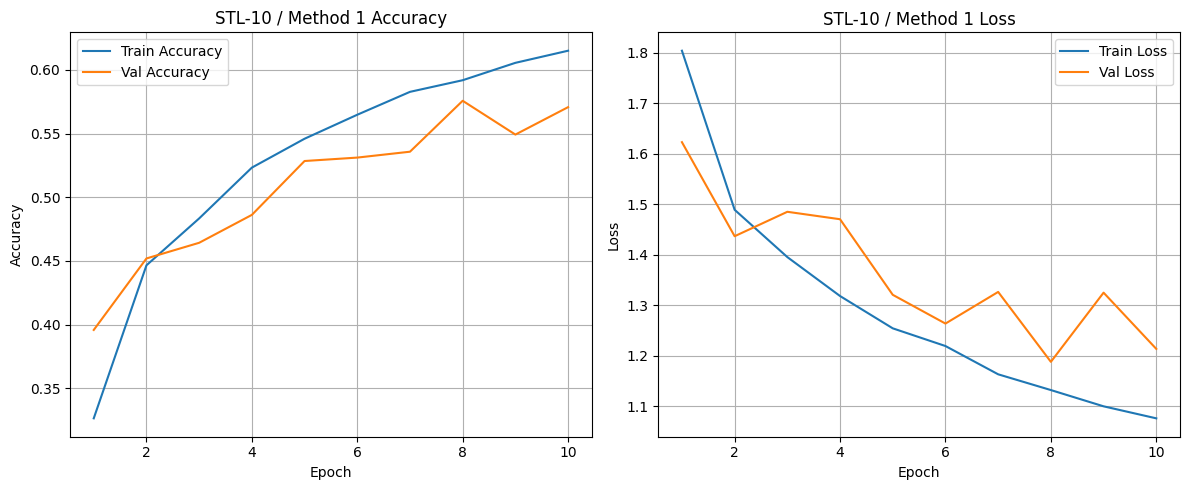


STL-10 - Method 2
Epoch 1/10
163/163 - 2s - 11ms/step - accuracy: 0.3204 - loss: 1.8184 - val_accuracy: 0.3854 - val_loss: 1.6353
Epoch 2/10
163/163 - 1s - 6ms/step - accuracy: 0.4398 - loss: 1.5013 - val_accuracy: 0.4738 - val_loss: 1.3796
Epoch 3/10
163/163 - 1s - 6ms/step - accuracy: 0.4934 - loss: 1.3825 - val_accuracy: 0.4996 - val_loss: 1.3498
Epoch 4/10
163/163 - 1s - 6ms/step - accuracy: 0.5248 - loss: 1.3007 - val_accuracy: 0.5077 - val_loss: 1.3506
Epoch 5/10
163/163 - 1s - 6ms/step - accuracy: 0.5503 - loss: 1.2380 - val_accuracy: 0.5504 - val_loss: 1.2329
Epoch 6/10
163/163 - 1s - 7ms/step - accuracy: 0.5677 - loss: 1.1872 - val_accuracy: 0.5631 - val_loss: 1.1843
Epoch 7/10
163/163 - 1s - 7ms/step - accuracy: 0.5894 - loss: 1.1371 - val_accuracy: 0.5596 - val_loss: 1.2438
Epoch 8/10
163/163 - 1s - 7ms/step - accuracy: 0.5999 - loss: 1.1003 - val_accuracy: 0.5723 - val_loss: 1.1682
Epoch 9/10
163/163 - 1s - 6ms/step - accuracy: 0.6167 - loss: 1.0645 - val_accuracy: 0.5850 

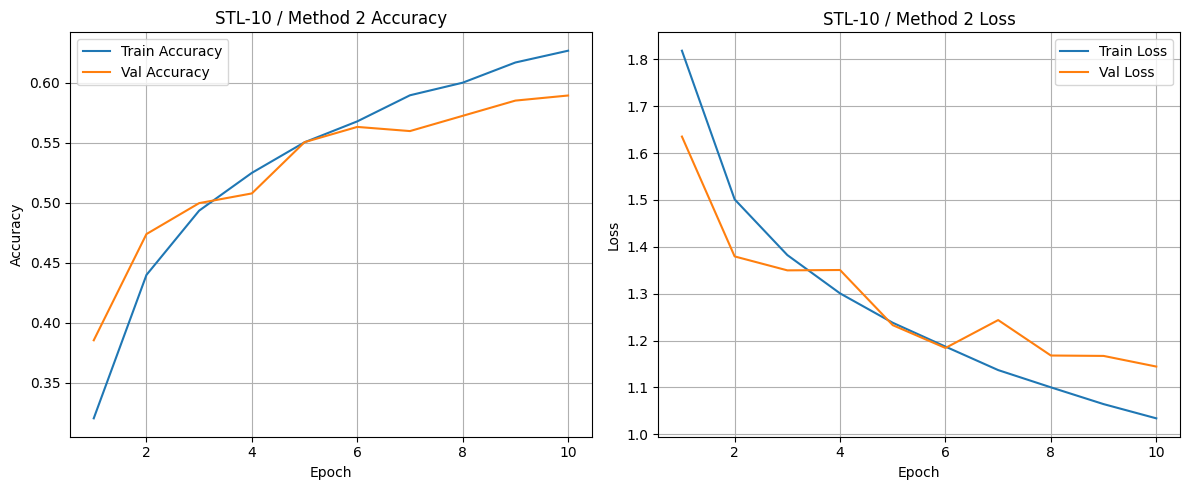


STL-10 - Method 3
Epoch 1/10
163/163 - 2s - 11ms/step - accuracy: 0.3063 - loss: 1.8691 - val_accuracy: 0.3935 - val_loss: 1.6311
Epoch 2/10
163/163 - 1s - 7ms/step - accuracy: 0.4358 - loss: 1.5179 - val_accuracy: 0.4481 - val_loss: 1.4897
Epoch 3/10
163/163 - 1s - 7ms/step - accuracy: 0.4809 - loss: 1.4083 - val_accuracy: 0.4792 - val_loss: 1.4297
Epoch 4/10
163/163 - 1s - 7ms/step - accuracy: 0.5200 - loss: 1.3234 - val_accuracy: 0.4838 - val_loss: 1.4362
Epoch 5/10
163/163 - 1s - 7ms/step - accuracy: 0.5455 - loss: 1.2467 - val_accuracy: 0.5427 - val_loss: 1.2748
Epoch 6/10
163/163 - 1s - 7ms/step - accuracy: 0.5663 - loss: 1.1830 - val_accuracy: 0.5292 - val_loss: 1.2990
Epoch 7/10
163/163 - 1s - 7ms/step - accuracy: 0.5939 - loss: 1.1230 - val_accuracy: 0.5227 - val_loss: 1.3330
Epoch 8/10
163/163 - 1s - 6ms/step - accuracy: 0.6237 - loss: 1.0518 - val_accuracy: 0.5481 - val_loss: 1.2734
Epoch 9/10
163/163 - 1s - 6ms/step - accuracy: 0.6413 - loss: 1.0005 - val_accuracy: 0.5631 

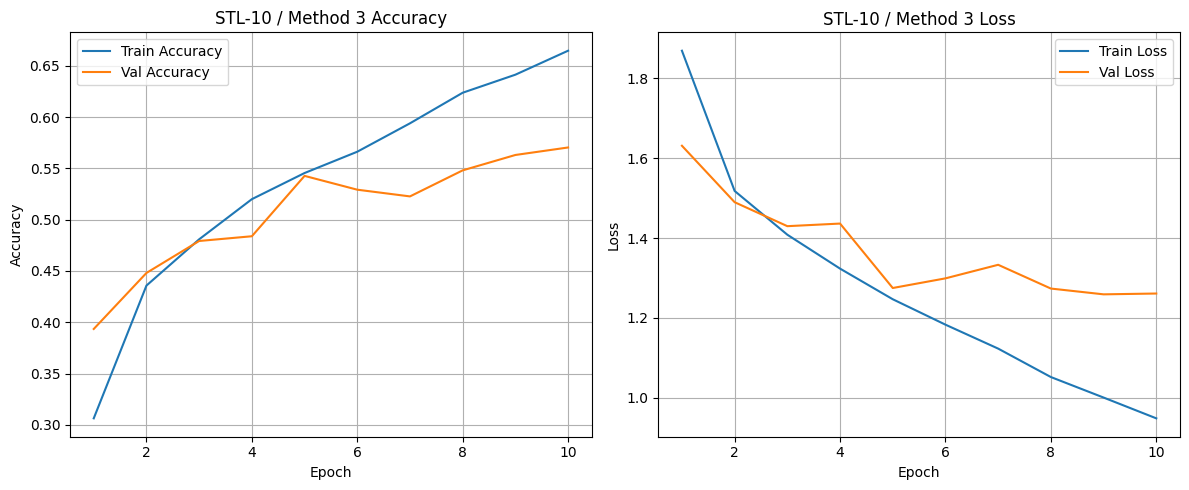


STL-10 - Method 4
Epoch 1/10
163/163 - 2s - 12ms/step - accuracy: 0.3143 - loss: 1.8503 - val_accuracy: 0.3431 - val_loss: 1.8485
Epoch 2/10
163/163 - 1s - 7ms/step - accuracy: 0.4189 - loss: 1.5619 - val_accuracy: 0.4085 - val_loss: 1.6230
Epoch 3/10
163/163 - 1s - 7ms/step - accuracy: 0.4512 - loss: 1.4829 - val_accuracy: 0.4073 - val_loss: 1.7181
Epoch 4/10
163/163 - 1s - 8ms/step - accuracy: 0.4791 - loss: 1.4270 - val_accuracy: 0.4427 - val_loss: 1.6153
Epoch 5/10
163/163 - 1s - 7ms/step - accuracy: 0.4957 - loss: 1.3806 - val_accuracy: 0.4750 - val_loss: 1.4618
Epoch 6/10
163/163 - 1s - 7ms/step - accuracy: 0.5085 - loss: 1.3368 - val_accuracy: 0.4842 - val_loss: 1.3901
Epoch 7/10
163/163 - 1s - 7ms/step - accuracy: 0.5224 - loss: 1.2933 - val_accuracy: 0.4804 - val_loss: 1.4559
Epoch 8/10
163/163 - 1s - 7ms/step - accuracy: 0.5378 - loss: 1.2686 - val_accuracy: 0.5515 - val_loss: 1.2541
Epoch 9/10
163/163 - 1s - 7ms/step - accuracy: 0.5465 - loss: 1.2437 - val_accuracy: 0.5238 

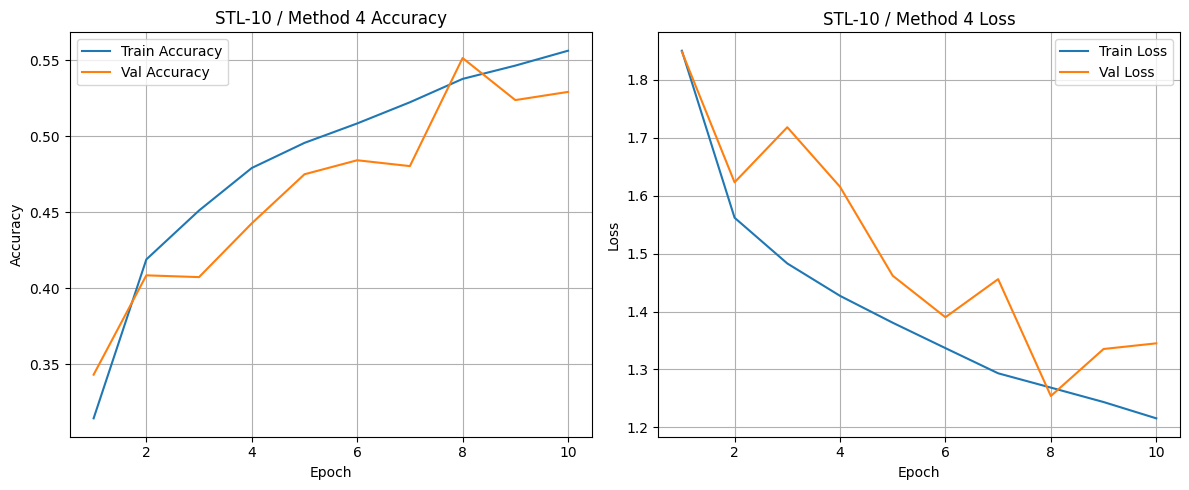


Final accuracy summary (STL-10):
Method 0: train_acc=0.7476, val_acc=0.5804
Method 1: train_acc=0.6151, val_acc=0.5708
Method 2: train_acc=0.6265, val_acc=0.5892
Method 3: train_acc=0.6647, val_acc=0.5704
Method 4: train_acc=0.5563, val_acc=0.5292


In [3]:
# EN: Load STL-10 labeled data from TFDS.
# CN: 从 TFDS 加载 STL-10（只用 labeled split）
ds_train = tfds.load("stl10", split="train", as_supervised=True)
ds_test  = tfds.load("stl10", split="test",  as_supervised=True)

def ds_to_numpy_resize(ds, target_size=(32, 32)):
    images, labels = [], []
    for x, y in tfds.as_numpy(ds):
        # EN: Resize 96x96 -> 32x32 for fair comparison and faster training.
        # CN: 将 96x96 resize 到 32x32，便于同模型对比且训练更快
        x = tf.image.resize(x, target_size).numpy().astype(np.uint8)
        images.append(x)
        labels.append(y)
    return np.stack(images), np.array(labels)

X0, y0 = ds_to_numpy_resize(ds_train, target_size=(32, 32))
X1, y1 = ds_to_numpy_resize(ds_test, target_size=(32, 32))

X = np.concatenate([X0, X1], axis=0)
y = np.concatenate([y0, y1], axis=0)

# EN: Normalize to [0,1].
# CN: 归一化到 [0,1]
X = X.astype("float32") / 255.0

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True
)

input_shape = (32, 32, 3)
num_classes = 10
is_rgb = True

results = {}

for method_id in range(5):
    print("\n==============================")
    print(f"STL-10 - Method {method_id}")
    print("==============================")

    history, train_acc, val_acc = run_one_method(
        X_train, y_train, X_val, y_val,
        input_shape=input_shape, num_classes=num_classes,
        method_id=method_id, is_rgb=is_rgb
    )
    results[method_id] = (train_acc, val_acc)
    plot_acc_loss(history, title_prefix=f"STL-10 / Method {method_id}")

print("\nFinal accuracy summary (STL-10):")
for k, (ta, va) in results.items():
    print(f"Method {k}: train_acc={ta:.4f}, val_acc={va:.4f}")

## Conclusion for STL-10 (TensorFlow Data Augmentation) 